# Лабораторная работа №2
### Однослойный перцептрон

Выполнено:
- обязательная часть;
- дополнительные задания 1, 2 и 5;

#### Библиотеки
- `numpy` — вычисления;
- `matplotlib` — графики;
- `make_classification` — генерация базового набора данных.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

np.set_printoptions(precision=4, suppress=True)


#### Вспомогательные функции

- стратифицированное разбиение;
- стандартизация;
- метрики;
- таблицы результатов.

In [ ]:
def stratified_train_test_split(X, y, test_size=0.3, random_state=42):
    rng = np.random.default_rng(random_state)

    train_indices = []
    test_indices = []

    for cls in np.unique(y):
        cls_indices = np.where(y == cls)[0]
        rng.shuffle(cls_indices)

        n_test = int(round(len(cls_indices) * test_size))

        test_indices.extend(cls_indices[:n_test])
        train_indices.extend(cls_indices[n_test:])

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)

    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]


def standardize_fit_transform(X_train, X_test):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    std = np.where(std == 0, 1, std)

    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std

    return X_train_scaled, X_test_scaled, mean, std


def apply_standardization(X, mean, std):
    std = np.where(std == 0, 1, std)
    return (X - mean) / std


def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)


def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn


def classification_metrics_manual(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix_manual(y_true, y_pred)

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def print_metrics(title, metrics):
    print(title)
    print("-" * len(title))
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")
    print()


def print_table(headers, rows):
    widths = [len(str(h)) for h in headers]

    for row in rows:
        for i, value in enumerate(row):
            widths[i] = max(widths[i], len(str(value)))

    header_line = " | ".join(str(h).ljust(widths[i]) for i, h in enumerate(headers))
    separator = "-+-".join("-" * w for w in widths)

    print(header_line)
    print(separator)

    for row in rows:
        print(" | ".join(str(value).ljust(widths[i]) for i, value in enumerate(row)))


#### Подготовка данных

Используется набор данных для бинарной классификации с двумя признаками:

- `n_samples = 500`;
- `n_features = 2`;
- `n_redundant = 0`;
- `n_informative = 2`;
- `random_state = 42`;
- `n_clusters_per_class = 1`.

Размер X: (500, 2)
Размер y: (500,)
Класс 0: 249
Класс 1: 251


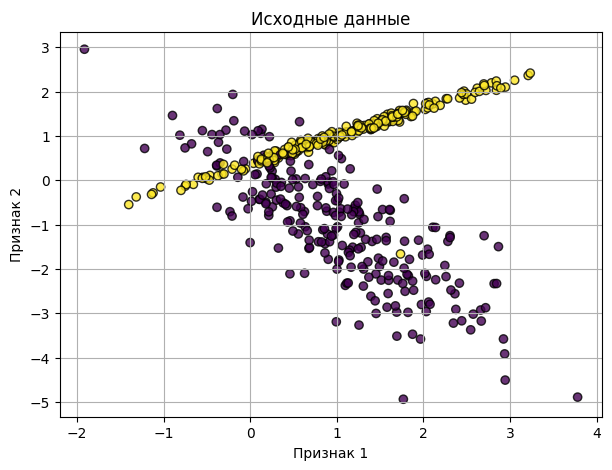

In [ ]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42,
    n_clusters_per_class=1
)

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Класс 0:", np.sum(y == 0))
print("Класс 1:", np.sum(y == 1))

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", alpha=0.8)
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.title("Исходные данные")
plt.grid(True)
plt.show()


#### Разбиение и стандартизация

Данные делятся на обучающую и тестовую выборки в пропорции 70/30 со стратификацией.

Стандартизация:

$$
x' = \frac{x - \mu}{\sigma}
$$

Среднее и стандартное отклонение считаются только по обучающей выборке.

In [ ]:
X_train, X_test, y_train, y_test = stratified_train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train_scaled, X_test_scaled, mean, std = standardize_fit_transform(X_train, X_test)

print("Train:", X_train_scaled.shape, y_train.shape)
print("Test:", X_test_scaled.shape, y_test.shape)

print("\nКлассы в train:")
print("0:", np.sum(y_train == 0), "1:", np.sum(y_train == 1))

print("\nКлассы в test:")
print("0:", np.sum(y_test == 0), "1:", np.sum(y_test == 1))

print("\nСреднее train после стандартизации:", np.mean(X_train_scaled, axis=0))
print("Std train после стандартизации:", np.std(X_train_scaled, axis=0))


Train: (350, 2) (350,)
Test: (150, 2) (150,)

Классы в train:
0: 174 1: 176

Классы в test:
0: 75 1: 75

Среднее train после стандартизации: [-0.  0.]
Std train после стандартизации: [1. 1.]


#### Реализация однослойного перцептрона

Модель:

$$
z = w^T x + b
$$

$$
\hat{y} = \sigma(z)
$$

Сигмоида:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Бинарная кросс-энтропия:

$$
L = -\frac{1}{m}\sum_{i=1}^{m}
\left(
y_i \log(\hat{y_i}) + (1-y_i)\log(1-\hat{y_i})
\right)
$$

Градиенты:

$$
\frac{\partial L}{\partial w} =
\frac{1}{m}X^T(\hat{y} - y)
$$

$$
\frac{\partial L}{\partial b} =
\frac{1}{m}\sum_{i=1}^{m}(\hat{y_i} - y_i)
$$

In [ ]:
class SingleLayerPerceptron:
    def __init__(
        self,
        n_features,
        init_type="small_random",
        loss_type="bce",
        l2_lambda=0.0,
        random_state=42,
    ):
        self.n_features = n_features
        self.init_type = init_type
        self.loss_type = loss_type
        self.l2_lambda = l2_lambda
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

        self.w = self._init_weights()
        self.b = 0.0

        self.train_losses = []
        self.test_losses = []

    def _init_weights(self):
        if self.init_type == "zeros":
            return np.zeros(self.n_features)

        if self.init_type == "small_random":
            return self.rng.normal(loc=0.0, scale=0.01, size=self.n_features)

        if self.init_type == "large_random":
            return self.rng.normal(loc=0.0, scale=10.0, size=self.n_features)

        raise ValueError("Неизвестный тип инициализации")

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def forward_linear(self, X):
        return X @ self.w + self.b

    def forward(self, X):
        return self.sigmoid(self.forward_linear(X))

    def compute_bce_loss(self, y_true, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.mean(
            y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
        )
        loss += 0.5 * self.l2_lambda * np.sum(self.w ** 2)
        return loss

    def compute_hinge_loss(self, y_true_pm, scores):
        margins = 1 - y_true_pm * scores
        loss = np.mean(np.maximum(0, margins))
        loss += 0.5 * self.l2_lambda * np.sum(self.w ** 2)
        return loss

    def compute_loss(self, y_true, X):
        if self.loss_type == "bce":
            y_pred = self.forward(X)
            return self.compute_bce_loss(y_true, y_pred)

        if self.loss_type == "hinge":
            y_true_pm = 2 * y_true - 1
            scores = self.forward_linear(X)
            return self.compute_hinge_loss(y_true_pm, scores)

        raise ValueError("Неизвестная функция потерь")

    def _bce_gradients(self, X_batch, y_batch):
        y_pred = self.forward(X_batch)
        error = y_pred - y_batch

        dw = (X_batch.T @ error) / len(X_batch)
        db = np.mean(error)

        dw += self.l2_lambda * self.w

        return dw, db

    def _hinge_gradients(self, X_batch, y_batch):
        y_batch_pm = 2 * y_batch - 1
        scores = self.forward_linear(X_batch)
        margins = 1 - y_batch_pm * scores
        active = margins > 0

        if np.any(active):
            dw = -np.mean(X_batch[active] * y_batch_pm[active, None], axis=0)
            db = -np.mean(y_batch_pm[active])
        else:
            dw = np.zeros_like(self.w)
            db = 0.0

        dw += self.l2_lambda * self.w

        return dw, db

    def fit(
        self,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=100,
        lr=0.1,
        batch_size=32,
    ):
        n_samples = X_train.shape[0]

        self.train_losses = []
        self.test_losses = []

        for epoch in range(epochs):
            indices = self.rng.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                if self.loss_type == "bce":
                    dw, db = self._bce_gradients(X_batch, y_batch)
                elif self.loss_type == "hinge":
                    dw, db = self._hinge_gradients(X_batch, y_batch)
                else:
                    raise ValueError("Неизвестная функция потерь")

                self.w -= lr * dw
                self.b -= lr * db

            train_loss = self.compute_loss(y_train, X_train)
            test_loss = self.compute_loss(y_test, X_test)

            self.train_losses.append(train_loss)
            self.test_losses.append(test_loss)

        return self

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X):
        if self.loss_type == "hinge":
            return (self.forward_linear(X) >= 0).astype(int)

        probabilities = self.predict_proba(X)
        return (probabilities >= 0.5).astype(int)


#### Базовое обучение


In [ ]:
base_model = SingleLayerPerceptron(
    n_features=X_train_scaled.shape[1],
    init_type="small_random",
    loss_type="bce",
    random_state=42
)

base_model.fit(
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    epochs=100,
    lr=0.1,
    batch_size=32
)

y_train_pred = base_model.predict(X_train_scaled)
y_test_pred = base_model.predict(X_test_scaled)

train_metrics = classification_metrics_manual(y_train, y_train_pred)
test_metrics = classification_metrics_manual(y_test, y_test_pred)

print_metrics("Метрики на обучающей выборке", train_metrics)
print_metrics("Метрики на тестовой выборке", test_metrics)


Метрики на обучающей выборке
----------------------------
TP: 160
TN: 148
FP: 26
FN: 16
accuracy: 0.8800
precision: 0.8602
recall: 0.9091
f1: 0.8840

Метрики на тестовой выборке
---------------------------
TP: 71
TN: 58
FP: 17
FN: 4
accuracy: 0.8600
precision: 0.8068
recall: 0.9467
f1: 0.8712



#### График функции потерь


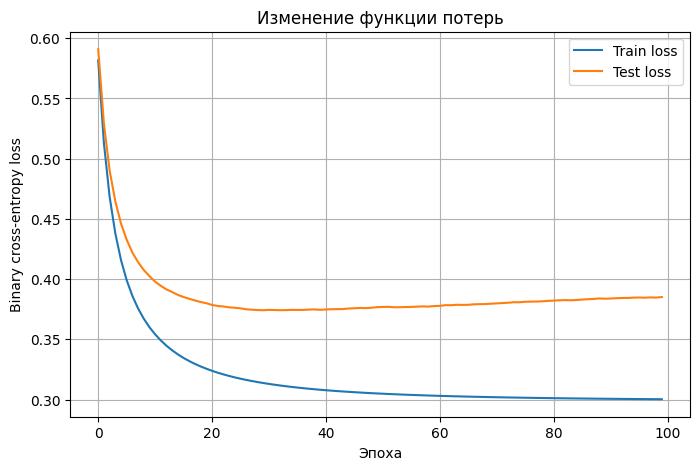

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(base_model.train_losses, label="Train loss")
plt.plot(base_model.test_losses, label="Test loss")
plt.xlabel("Эпоха")
plt.ylabel("Binary cross-entropy loss")
plt.title("Изменение функции потерь")
plt.legend()
plt.grid(True)
plt.show()


#### Визуализация разделяющей границы

Граница решения задаётся уравнением:

$$
w_1x_1 + w_2x_2 + b = 0
$$

Отсюда:

$$
x_2 = -\frac{w_1x_1 + b}{w_2}
$$

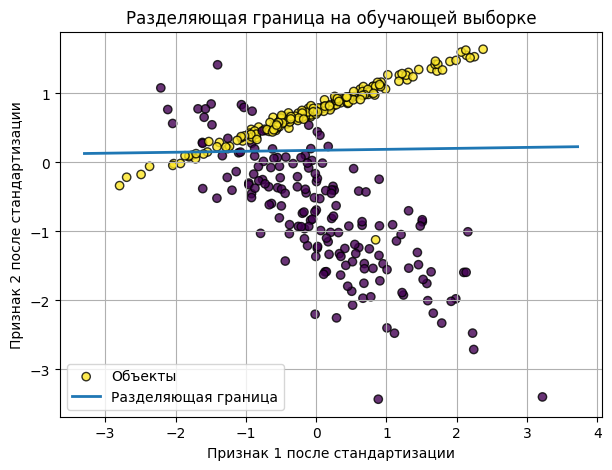

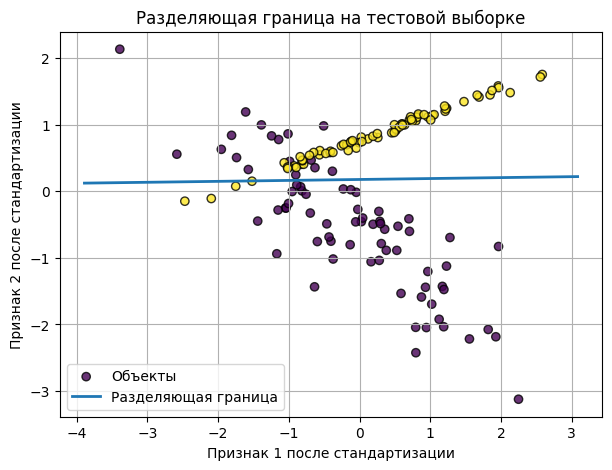

In [ ]:
def plot_decision_boundary(model, X, y, title, wrong_mask=None):
    plt.figure(figsize=(7, 5))

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", alpha=0.8, label="Объекты")

    if wrong_mask is not None and np.any(wrong_mask):
        plt.scatter(
            X[wrong_mask, 0],
            X[wrong_mask, 1],
            facecolors="none",
            edgecolors="red",
            s=130,
            linewidths=2,
            label="Ошибки"
        )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x_values = np.linspace(x_min, x_max, 200)

    if abs(model.w[1]) > 1e-12:
        y_values = -(model.w[0] * x_values + model.b) / model.w[1]
        plt.plot(x_values, y_values, linewidth=2, label="Разделяющая граница")
    elif abs(model.w[0]) > 1e-12:
        x_boundary = -model.b / model.w[0]
        plt.axvline(x_boundary, linewidth=2, label="Разделяющая граница")

    plt.xlabel("Признак 1 после стандартизации")
    plt.ylabel("Признак 2 после стандартизации")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_decision_boundary(
    base_model,
    X_train_scaled,
    y_train,
    "Разделяющая граница на обучающей выборке"
)

plot_decision_boundary(
    base_model,
    X_test_scaled,
    y_test,
    "Разделяющая граница на тестовой выборке"
)


#### Эксперимент: влияние скорости обучения

Проверяются значения:

- `0.001`;
- `0.01`;
- `0.5`;
- `1.0`.

Остальные параметры фиксированы.

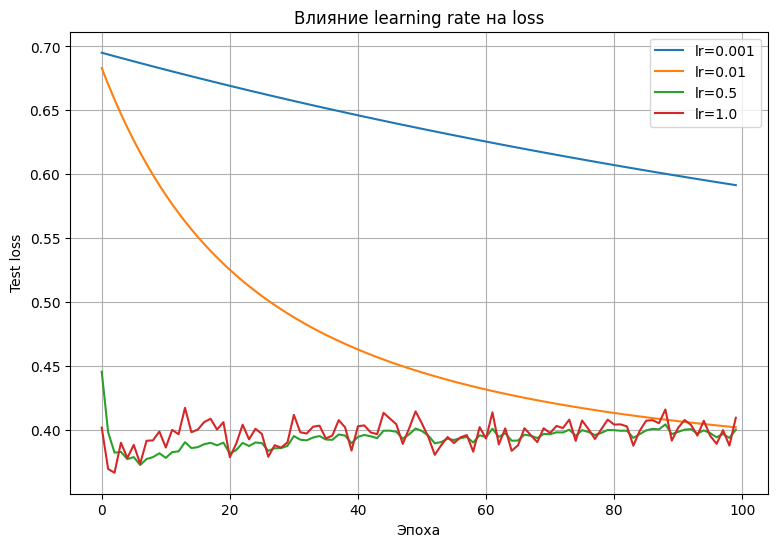

lr    | train_acc | test_acc | final_train_loss | final_test_loss
------+-----------+----------+------------------+----------------
0.001 | 0.8771    | 0.8333   | 0.5826           | 0.5915         
0.01  | 0.8714    | 0.8533   | 0.3604           | 0.4021         
0.5   | 0.8886    | 0.8667   | 0.2992           | 0.4003         
1.0   | 0.8914    | 0.8667   | 0.3000           | 0.4096         


In [ ]:
def run_experiment(
    lr=0.1,
    batch_size=32,
    init_type="small_random",
    epochs=100,
    loss_type="bce",
    l2_lambda=0.0,
    random_state=42,
):
    model = SingleLayerPerceptron(
        n_features=X_train_scaled.shape[1],
        init_type=init_type,
        loss_type=loss_type,
        l2_lambda=l2_lambda,
        random_state=random_state
    )

    model.fit(
        X_train_scaled,
        y_train,
        X_test_scaled,
        y_test,
        epochs=epochs,
        lr=lr,
        batch_size=batch_size
    )

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score_manual(y_train, train_pred)
    test_acc = accuracy_score_manual(y_test, test_pred)

    return model, train_acc, test_acc


learning_rates = [0.001, 0.01, 0.5, 1.0]
lr_results = []

plt.figure(figsize=(9, 6))

for lr in learning_rates:
    model, train_acc, test_acc = run_experiment(lr=lr, batch_size=32, init_type="small_random")
    lr_results.append([
        lr,
        f"{train_acc:.4f}",
        f"{test_acc:.4f}",
        f"{model.train_losses[-1]:.4f}",
        f"{model.test_losses[-1]:.4f}"
    ])

    plt.plot(model.test_losses, label=f"lr={lr}")

plt.xlabel("Эпоха")
plt.ylabel("Test loss")
plt.title("Влияние learning rate на loss")
plt.legend()
plt.grid(True)
plt.show()

print_table(
    ["lr", "train_acc", "test_acc", "final_train_loss", "final_test_loss"],
    lr_results
)


#### Эксперимент: влияние размера батча

Проверяются значения:

- `1`;
- `16`;
- `64`;
- `256`.

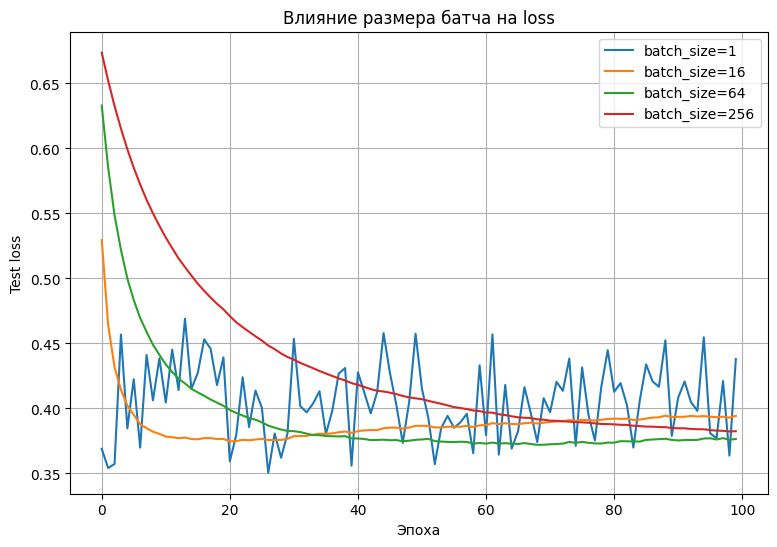

batch_size | train_acc | test_acc | final_train_loss | final_test_loss
-----------+-----------+----------+------------------+----------------
1          | 0.9000    | 0.8667   | 0.3052           | 0.4380         
16         | 0.8829    | 0.8667   | 0.2992           | 0.3942         
64         | 0.8800    | 0.8600   | 0.3042           | 0.3765         
256        | 0.8800    | 0.8667   | 0.3290           | 0.3824         


In [ ]:
batch_sizes = [1, 16, 64, 256]
batch_results = []

plt.figure(figsize=(9, 6))

for batch_size in batch_sizes:
    model, train_acc, test_acc = run_experiment(
        lr=0.1,
        batch_size=batch_size,
        init_type="small_random"
    )

    batch_results.append([
        batch_size,
        f"{train_acc:.4f}",
        f"{test_acc:.4f}",
        f"{model.train_losses[-1]:.4f}",
        f"{model.test_losses[-1]:.4f}"
    ])

    plt.plot(model.test_losses, label=f"batch_size={batch_size}")

plt.xlabel("Эпоха")
plt.ylabel("Test loss")
plt.title("Влияние размера батча на loss")
plt.legend()
plt.grid(True)
plt.show()

print_table(
    ["batch_size", "train_acc", "test_acc", "final_train_loss", "final_test_loss"],
    batch_results
)


#### Эксперимент: влияние инициализации весов

Сравниваются:
- нулевая инициализация;
- маленькие случайные веса;
- большие случайные веса из распределения $N(0, 10)$.

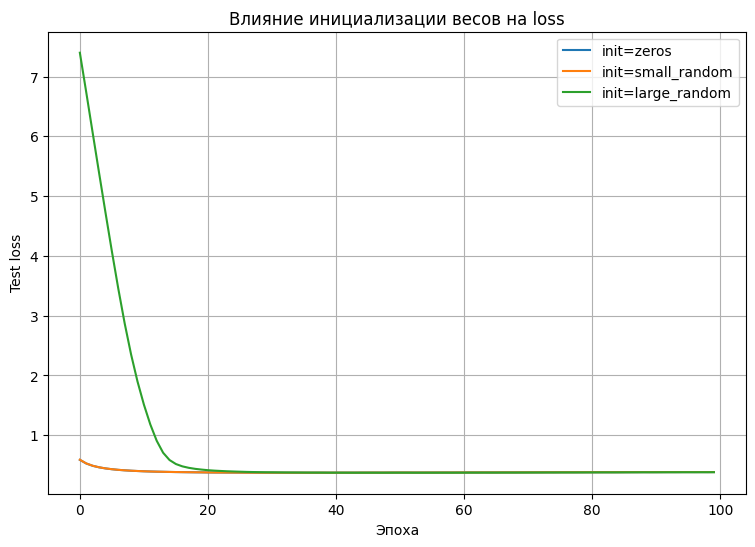

init_type    | train_acc | test_acc | final_train_loss | final_test_loss
-------------+-----------+----------+------------------+----------------
zeros        | 0.8800    | 0.8600   | 0.3002           | 0.3851         
small_random | 0.8800    | 0.8600   | 0.3002           | 0.3851         
large_random | 0.8800    | 0.8600   | 0.3008           | 0.3828         


In [ ]:
init_types = ["zeros", "small_random", "large_random"]
init_results = []

plt.figure(figsize=(9, 6))

for init_type in init_types:
    model, train_acc, test_acc = run_experiment(
        lr=0.1,
        batch_size=32,
        init_type=init_type
    )

    init_results.append([
        init_type,
        f"{train_acc:.4f}",
        f"{test_acc:.4f}",
        f"{model.train_losses[-1]:.4f}",
        f"{model.test_losses[-1]:.4f}"
    ])

    plt.plot(model.test_losses, label=f"init={init_type}")

plt.xlabel("Эпоха")
plt.ylabel("Test loss")
plt.title("Влияние инициализации весов на loss")
plt.legend()
plt.grid(True)
plt.show()

print_table(
    ["init_type", "train_acc", "test_acc", "final_train_loss", "final_test_loss"],
    init_results
)


#### Дополнительное задание 1. Собственный генератор данных

Реализуются три варианта синтетических данных:
- линейно разделимые гауссовы облака;
- XOR;
- окружность.

Также добавляется шум: метка меняется с вероятностью `noise`.

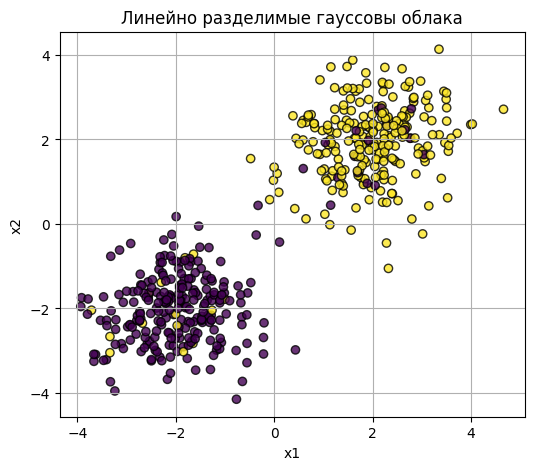

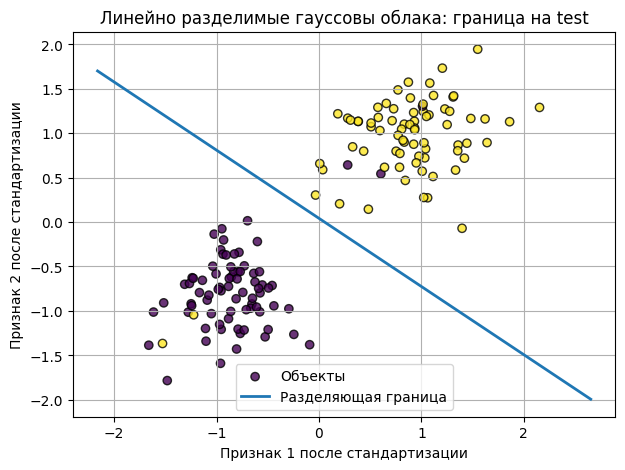

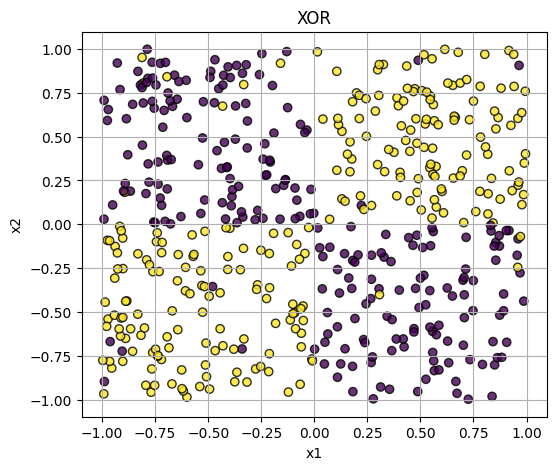

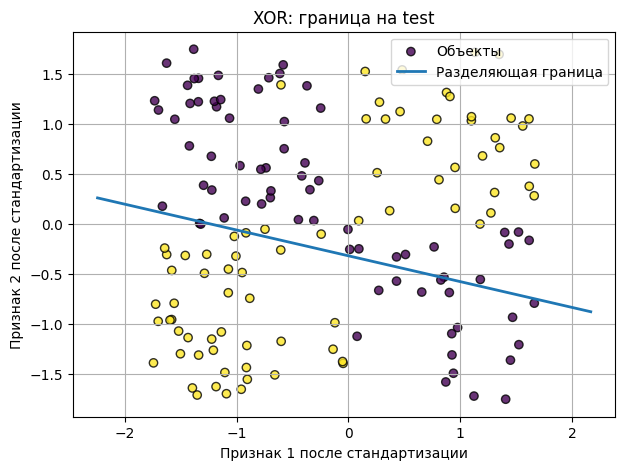

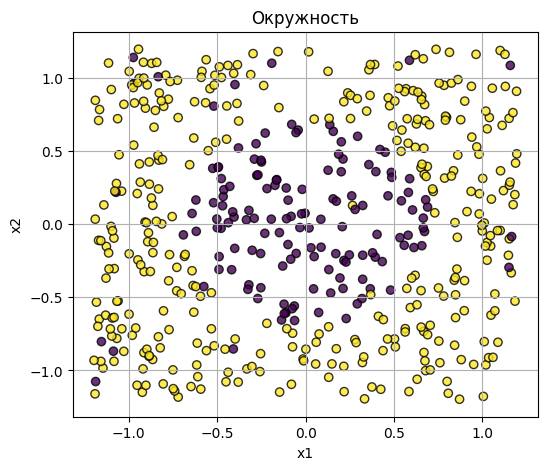

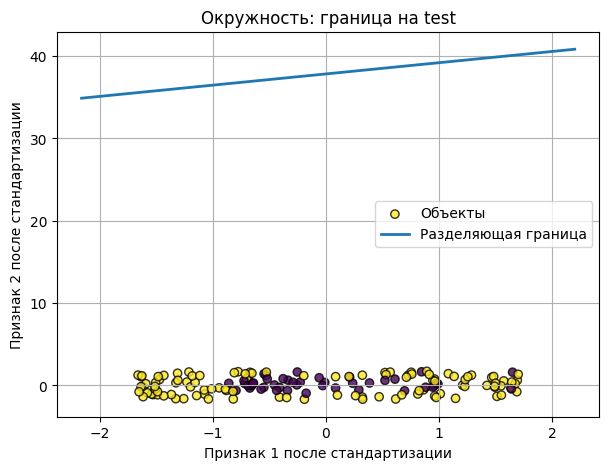

dataset                            | accuracy | precision | recall | f1    
-----------------------------------+----------+-----------+--------+-------
Линейно разделимые гауссовы облака | 0.9667   | 0.9600    | 0.9730 | 0.9664
XOR                                | 0.3600   | 0.3933    | 0.4545 | 0.4217
Окружность                         | 0.7067   | 0.7067    | 1.0000 | 0.8281


In [ ]:
def flip_labels(y, noise=0.0, random_state=42):
    rng = np.random.default_rng(random_state)
    y_noisy = y.copy()
    mask = rng.random(len(y)) < noise
    y_noisy[mask] = 1 - y_noisy[mask]
    return y_noisy


def generate_linear_gaussians(
    n_samples=500,
    centers=((-2, -2), (2, 2)),
    covariance=((0.7, 0), (0, 0.7)),
    noise=0.0,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    n_class_zero = n_samples // 2
    n_class_one = n_samples - n_class_zero

    X_zero = rng.multivariate_normal(centers[0], covariance, size=n_class_zero)
    X_one = rng.multivariate_normal(centers[1], covariance, size=n_class_one)

    X_data = np.vstack([X_zero, X_one])
    y_data = np.array([0] * n_class_zero + [1] * n_class_one)

    indices = rng.permutation(n_samples)
    X_data = X_data[indices]
    y_data = y_data[indices]

    y_data = flip_labels(y_data, noise=noise, random_state=random_state + 1)

    return X_data, y_data


def generate_xor(n_samples=500, noise=0.0, random_state=42):
    rng = np.random.default_rng(random_state)

    X_data = rng.uniform(-1, 1, size=(n_samples, 2))
    y_data = (X_data[:, 0] * X_data[:, 1] > 0).astype(int)
    y_data = flip_labels(y_data, noise=noise, random_state=random_state + 1)

    return X_data, y_data


def generate_circle(n_samples=500, radius=0.7, noise=0.0, random_state=42):
    rng = np.random.default_rng(random_state)

    X_data = rng.uniform(-1.2, 1.2, size=(n_samples, 2))
    distances = np.sqrt(X_data[:, 0] ** 2 + X_data[:, 1] ** 2)
    y_data = (distances > radius).astype(int)
    y_data = flip_labels(y_data, noise=noise, random_state=random_state + 1)

    return X_data, y_data


def train_on_custom_dataset(X_custom, y_custom, title):
    X_custom_train, X_custom_test, y_custom_train, y_custom_test = (
        stratified_train_test_split(
            X_custom,
            y_custom,
            test_size=0.3,
            random_state=42,
        )
    )
    X_custom_train_scaled, X_custom_test_scaled, _, _ = standardize_fit_transform(
        X_custom_train,
        X_custom_test,
    )

    model = SingleLayerPerceptron(
        n_features=2,
        init_type="small_random",
        loss_type="bce",
        random_state=42,
    )

    model.fit(
        X_custom_train_scaled,
        y_custom_train,
        X_custom_test_scaled,
        y_custom_test,
        epochs=100,
        lr=0.1,
        batch_size=32,
    )

    y_custom_pred = model.predict(X_custom_test_scaled)
    metrics = classification_metrics_manual(y_custom_test, y_custom_pred)

    plt.figure(figsize=(6, 5))
    plt.scatter(X_custom[:, 0], X_custom[:, 1], c=y_custom, edgecolor="k", alpha=0.8)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True)
    plt.show()

    plot_decision_boundary(
        model,
        X_custom_test_scaled,
        y_custom_test,
        title + ": граница на test",
    )

    return model, metrics


datasets = [
    (
        "Линейно разделимые гауссовы облака",
        generate_linear_gaussians(noise=0.05, random_state=42),
    ),
    ("XOR", generate_xor(noise=0.03, random_state=42)),
    ("Окружность", generate_circle(noise=0.03, random_state=42)),
]

custom_results = []

for title, (X_custom, y_custom) in datasets:
    model, metrics = train_on_custom_dataset(X_custom, y_custom, title)
    custom_results.append(
        [
            title,
            f"{metrics['accuracy']:.4f}",
            f"{metrics['precision']:.4f}",
            f"{metrics['recall']:.4f}",
            f"{metrics['f1']:.4f}",
        ]
    )

print_table(
    ["dataset", "accuracy", "precision", "recall", "f1"],
    custom_results,
)


#### Дополнительное задание 2. Hinge loss и L2-регуляризация

Hinge loss

Для Hinge loss используются метки:

$$
y \in \{-1, +1\}
$$

**Функция потерь:**

$$
L = \frac{1}{m}\sum_{i=1}^{m}\max(0, 1 - y_i z_i)
$$

где:

$$
z_i = w^T x_i + b
$$

**L2-регуляризация:**

К функции потерь добавляется штраф за большие веса:

$$
L_{reg} = L + \frac{\lambda}{2}\sum_j w_j^2
$$

Это помогает ограничивать величину весов и снижать переобучение.

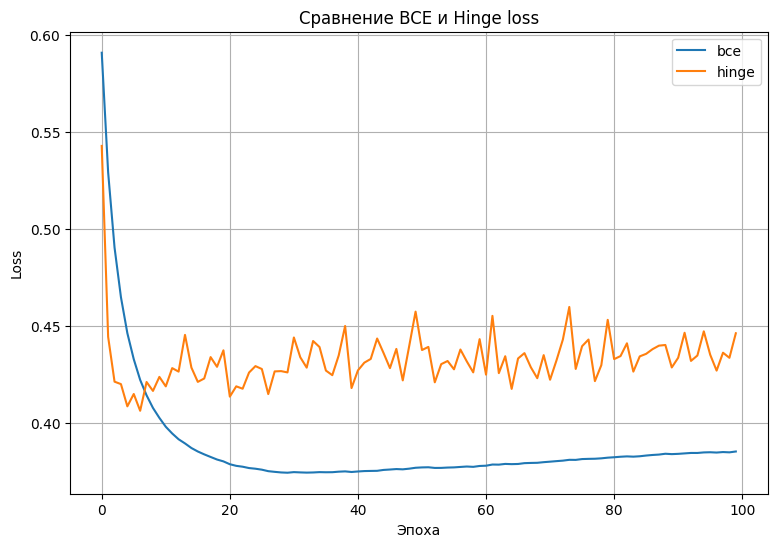

loss_type | train_acc | test_acc | final_train_loss | final_test_loss
----------+-----------+----------+------------------+----------------
bce       | 0.8800    | 0.8600   | 0.3002           | 0.3851         
hinge     | 0.9171    | 0.8800   | 0.2618           | 0.4461         


In [ ]:
loss_results = []

plt.figure(figsize=(9, 6))

for loss_type in ["bce", "hinge"]:
    model, train_acc, test_acc = run_experiment(
        lr=0.1,
        batch_size=32,
        init_type="small_random",
        epochs=100,
        loss_type=loss_type
    )

    loss_results.append([
        loss_type,
        f"{train_acc:.4f}",
        f"{test_acc:.4f}",
        f"{model.train_losses[-1]:.4f}",
        f"{model.test_losses[-1]:.4f}"
    ])

    plt.plot(model.test_losses, label=loss_type)

plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Сравнение BCE и Hinge loss")
plt.legend()
plt.grid(True)
plt.show()

print_table(
    ["loss_type", "train_acc", "test_acc", "final_train_loss", "final_test_loss"],
    loss_results
)


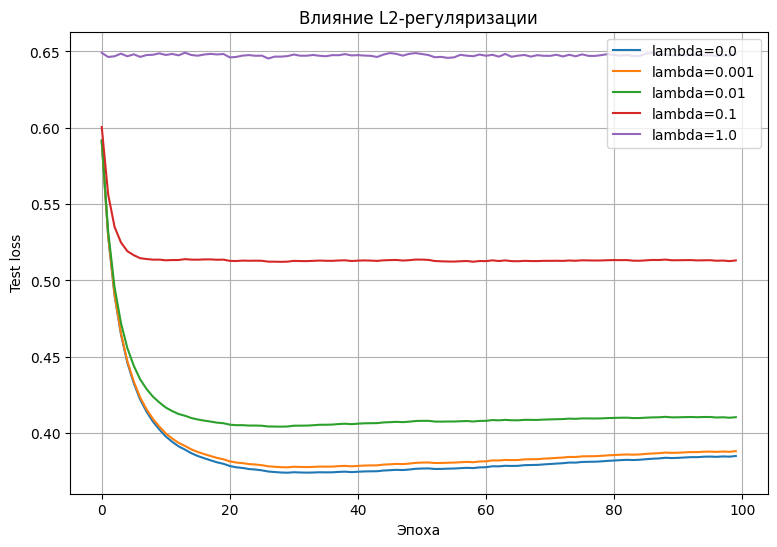

lambda | train_acc | test_acc | ||w||  | final_test_loss
-------+-----------+----------+--------+----------------
0.0    | 0.8800    | 0.8600   | 3.5166 | 0.3851         
0.001  | 0.8800    | 0.8600   | 3.3962 | 0.3883         
0.01   | 0.8800    | 0.8667   | 2.6712 | 0.4105         
0.1    | 0.8743    | 0.8533   | 1.2451 | 0.5132         
1.0    | 0.8714    | 0.8333   | 0.2951 | 0.6486         


In [ ]:
lambdas = [0.0, 0.001, 0.01, 0.1, 1.0]
l2_results = []

plt.figure(figsize=(9, 6))

for l2_lambda in lambdas:
    model, train_acc, test_acc = run_experiment(
        lr=0.1,
        batch_size=32,
        init_type="small_random",
        epochs=100,
        loss_type="bce",
        l2_lambda=l2_lambda
    )

    weight_norm = np.linalg.norm(model.w)

    l2_results.append([
        l2_lambda,
        f"{train_acc:.4f}",
        f"{test_acc:.4f}",
        f"{weight_norm:.4f}",
        f"{model.test_losses[-1]:.4f}"
    ])

    plt.plot(model.test_losses, label=f"lambda={l2_lambda}")

plt.xlabel("Эпоха")
plt.ylabel("Test loss")
plt.title("Влияние L2-регуляризации")
plt.legend()
plt.grid(True)
plt.show()

print_table(
    ["lambda", "train_acc", "test_acc", "||w||", "final_test_loss"],
    l2_results
)


#### Дополнительное задание 5. 5-кратная кросс-валидация

Реализуется 5-кратная кросс-валидация для подбора:
- learning rate;
- batch size.

Для каждой пары гиперпараметров считаются:
- средняя accuracy;
- стандартное отклонение accuracy.

In [ ]:
def stratified_kfold_indices(y, n_splits=5, random_state=42):
    rng = np.random.default_rng(random_state)
    folds = [[] for _ in range(n_splits)]

    for cls in np.unique(y):
        cls_indices = np.where(y == cls)[0]
        rng.shuffle(cls_indices)

        split_indices = np.array_split(cls_indices, n_splits)

        for fold_id, part in enumerate(split_indices):
            folds[fold_id].extend(part.tolist())

    folds = [np.array(fold) for fold in folds]
    return folds


def cross_validate_perceptron(
    X_data,
    y_data,
    lrs,
    batch_sizes,
    n_splits=5,
    epochs=100,
):
    folds = stratified_kfold_indices(y_data, n_splits=n_splits, random_state=42)
    results = []

    for lr in lrs:
        for batch_size in batch_sizes:
            fold_scores = []

            for fold_id in range(n_splits):
                validation_indices = folds[fold_id]
                train_indices = np.concatenate(
                    [folds[i] for i in range(n_splits) if i != fold_id]
                )

                X_fold_train = X_data[train_indices]
                y_fold_train = y_data[train_indices]
                X_fold_validation = X_data[validation_indices]
                y_fold_validation = y_data[validation_indices]

                X_fold_train_scaled, X_fold_validation_scaled, _, _ = (
                    standardize_fit_transform(X_fold_train, X_fold_validation)
                )

                model = SingleLayerPerceptron(
                    n_features=X_fold_train_scaled.shape[1],
                    init_type="small_random",
                    loss_type="bce",
                    random_state=42 + fold_id,
                )

                model.fit(
                    X_fold_train_scaled,
                    y_fold_train,
                    X_fold_validation_scaled,
                    y_fold_validation,
                    epochs=epochs,
                    lr=lr,
                    batch_size=batch_size,
                )

                y_fold_pred = model.predict(X_fold_validation_scaled)
                fold_scores.append(
                    accuracy_score_manual(y_fold_validation, y_fold_pred)
                )

            results.append(
                {
                    "lr": lr,
                    "batch_size": batch_size,
                    "mean_accuracy": float(np.mean(fold_scores)),
                    "std_accuracy": float(np.std(fold_scores)),
                }
            )

    return results


cv_lrs = [0.001, 0.01, 0.1, 0.5]
cv_batch_sizes = [16, 32, 64, 256]

cv_results = cross_validate_perceptron(
    X_train,
    y_train,
    lrs=cv_lrs,
    batch_sizes=cv_batch_sizes,
    n_splits=5,
    epochs=100,
)

cv_rows = []
for result in cv_results:
    cv_rows.append(
        [
            result["lr"],
            result["batch_size"],
            f"{result['mean_accuracy']:.4f}",
            f"{result['std_accuracy']:.4f}",
        ]
    )

print_table(
    ["lr", "batch_size", "mean_accuracy", "std_accuracy"],
    cv_rows,
)

best_result = max(cv_results, key=lambda item: item["mean_accuracy"])

print("\nЛучшие гиперпараметры:")
print(best_result)


lr    | batch_size | mean_accuracy | std_accuracy
------+------------+---------------+-------------
0.001 | 16         | 0.8770        | 0.0372      
0.001 | 32         | 0.8770        | 0.0372      
0.001 | 64         | 0.8770        | 0.0372      
0.001 | 256        | 0.8684        | 0.0270      
0.01  | 16         | 0.8769        | 0.0416      
0.01  | 32         | 0.8742        | 0.0422      
0.01  | 64         | 0.8771        | 0.0336      
0.01  | 256        | 0.8742        | 0.0390      
0.1   | 16         | 0.8826        | 0.0405      
0.1   | 32         | 0.8826        | 0.0405      
0.1   | 64         | 0.8826        | 0.0405      
0.1   | 256        | 0.8769        | 0.0416      
0.5   | 16         | 0.8941        | 0.0350      
0.5   | 32         | 0.8826        | 0.0405      
0.5   | 64         | 0.8854        | 0.0440      
0.5   | 256        | 0.8855        | 0.0409      

Лучшие гиперпараметры:
{'lr': 0.5, 'batch_size': 16, 'mean_accuracy': 0.8940740092730295, 'std_accu

# Финальная модель с лучшими гиперпараметрами

Финальная модель: train
-----------------------
TP: 166
TN: 146
FP: 28
FN: 10
accuracy: 0.8914
precision: 0.8557
recall: 0.9432
f1: 0.8973

Финальная модель: test
----------------------
TP: 72
TN: 58
FP: 17
FN: 3
accuracy: 0.8667
precision: 0.8090
recall: 0.9600
f1: 0.8780



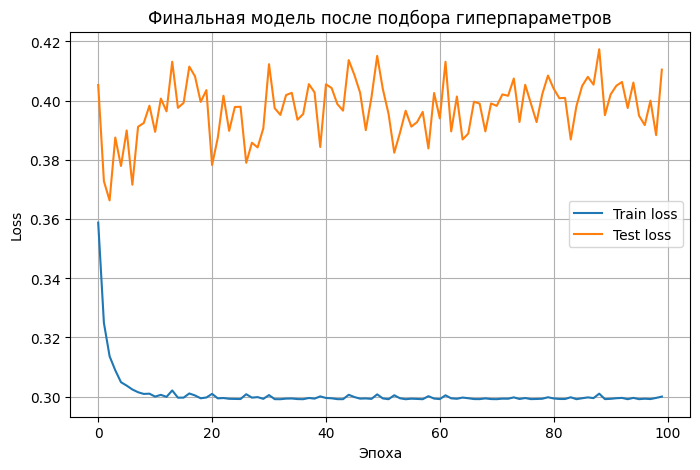

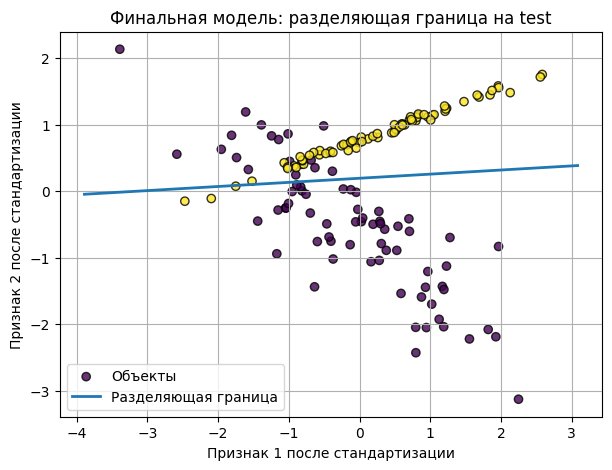

In [ ]:
best_lr = best_result["lr"]
best_batch_size = best_result["batch_size"]

final_model = SingleLayerPerceptron(
    n_features=X_train_scaled.shape[1],
    init_type="small_random",
    loss_type="bce",
    random_state=42
)

final_model.fit(
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    epochs=100,
    lr=best_lr,
    batch_size=best_batch_size
)

final_train_pred = final_model.predict(X_train_scaled)
final_test_pred = final_model.predict(X_test_scaled)

final_train_metrics = classification_metrics_manual(y_train, final_train_pred)
final_test_metrics = classification_metrics_manual(y_test, final_test_pred)

print_metrics("Финальная модель: train", final_train_metrics)
print_metrics("Финальная модель: test", final_test_metrics)

plt.figure(figsize=(8, 5))
plt.plot(final_model.train_losses, label="Train loss")
plt.plot(final_model.test_losses, label="Test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Финальная модель после подбора гиперпараметров")
plt.legend()
plt.grid(True)
plt.show()

plot_decision_boundary(
    final_model,
    X_test_scaled,
    y_test,
    "Финальная модель: разделяющая граница на test"
)


# Итоговый выводы

В лабораторной работе реализован однослойный перцептрон для бинарной классификации.  
Была выполнена подготовка данных: стратифицированное разбиение и стандартизация признаков по обучающей выборке.  

Перцептрон реализован с нуля.

Были проведены обязательные эксперименты:
- влияние скорости обучения;
- влияние размера батча;
- влияние инициализации весов.

Также выполнены дополнительные задания(1,2,5).

Основной вывод: однослойный перцептрон строит линейную разделяющую границу, поэтому хорошо работает на линейно разделимых данных, но плохо подходит для задач вроде XOR и окружности, где нужна нелинейная граница.